# Tạo dataset
Tận dụng nhãn đã có từ các task trước gồm:

- mental_state (7 lớp, đã gán nhãn thật + giả)

- sentiment_intensity (4 lớp, đã xử lý mất cân bằng)

Từ đó mapping về 3 lớp gating theo logic mà bạn đã từng phác thảo, ví dụ:

| mental\_state               | sentiment\_intensity | Gating Label   |
| --------------------------- | -------------------- | -------------- |
| Normal                      | 0 (nhẹ)              | 🟢 `normal`    |
| Stress, Anxiety             | 1–2                  | 🟡 `risky`     |
| Suicidal, Depression (nặng) | 3                    | 🔴 `emergency` |


Dùng gating model làm step đầu tiên, giúp tối ưu pipeline bằng cách:

- Bỏ qua bước sentiment/mental_state nếu không cần thiết

- Giảm chi phí tính toán

- Tăng tốc độ phản hồi

- Đồng thời giúp kích hoạt mô-đun khẩn cấp nếu cần thiết.



## Bước 1: Tạo nhãn gating từ setiment + mental-state

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Load các file nhãn (chứa user message, mental_state, sentiment)
df_sentiment = pd.read_csv("setiment_label.csv")   # ['question', 'sentiment_intensity']
df_mental = pd.read_csv("augmented_labeled_full.csv")   # ['message', 'mental_state']

# Chuẩn hóa về cùng cột 'text'
df_sentiment = df_sentiment.rename(columns={'question': 'text'})
df_mental = df_mental.rename(columns={'statement': 'text'})

# Gộp lại theo 'text' (inner join)
df_merged = pd.merge(df_sentiment, df_mental, on='text', how='outer')

# Mapping mental/sentiment thành severity score
def get_severity(row):
    score = 0
    # Sentiment
    if pd.notna(row['intensity']):
        score = max(score, int(row['intensity']))
    # Mental
    risky = ['Stress', 'Anxiety', 'Bipolar', 'Personality disorder']
    emergency = ['Suicidal', 'Depression']
    if pd.notna(row['label']):
        if row['label'] in risky:
            score = max(score, 2)
        elif row['label'] in emergency:
            score = max(score, 3)
    return score

df_merged['severity'] = df_merged.apply(get_severity, axis=1)

# Mapping severity → gating_label
def severity_to_label(s):
    if s == 0:
        return 'normal'
    elif s in [1, 2]:
        return 'risky'
    else:
        return 'emergency'

df_merged['gating_label'] = df_merged['severity'].apply(severity_to_label)

# Loại bỏ các dòng không có 'text' hoặc 'gating_label'
df_labeled = df_merged[['text', 'gating_label']].dropna()
df_labeled = df_labeled.drop_duplicates()



In [3]:
label_counts = df_labeled['gating_label'].value_counts()

In [4]:
from sklearn.utils import resample
# Mục tiêu mỗi nhãn
target_per_class = 25000

dfs = []
for label in ['normal', 'risky', 'emergency']:
    df_label = df_labeled[df_labeled['gating_label'] == label]
    if len(df_label) > target_per_class:
        df_label_balanced = df_label.sample(n=target_per_class, random_state=42)
    else:
        df_label_balanced = resample(df_label, replace=True, n_samples=target_per_class, random_state=42)
    dfs.append(df_label_balanced)

df_balanced = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)


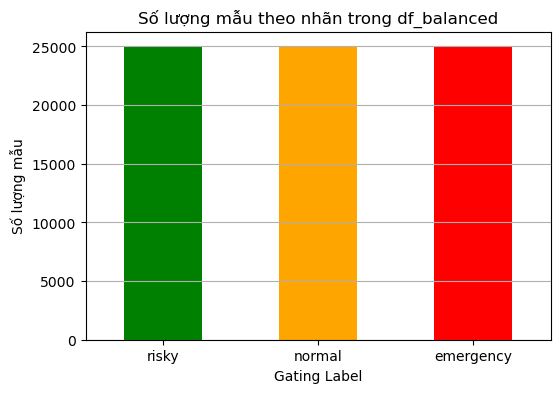

In [5]:
import matplotlib.pyplot as plt

# Đếm số lượng mỗi nhãn trong df_balanced
label_counts = df_balanced['gating_label'].value_counts()

# Vẽ biểu đồ cột
plt.figure(figsize=(6,4))
label_counts.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Số lượng mẫu theo nhãn trong df_balanced')
plt.xlabel('Gating Label')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [6]:
from torch.utils.data import Dataset
from transformers import AutoTokenizer

class GatingDataset(Dataset):
    def __init__(self, dataframe, tokenizer, label2id, max_length=128):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data.iloc[idx]['text']
        label = self.label2id[self.data.iloc[idx]['gating_label']]
        encoding = self.tokenizer(text, truncation=True, padding='max_length', max_length=self.max_length, return_tensors='pt')
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}
        encoding['labels'] = label
        return encoding


In [7]:
import torch
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

model_name = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
devices = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3).to(devices)

# Mapping label
label2id = {'normal': 0, 'risky': 1, 'emergency': 2}
id2label = {v: k for k, v in label2id.items()}

# Stratified split
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(df_balanced, test_size=0.1, stratify=df_balanced['gating_label'], random_state=42)

train_dataset = GatingDataset(df_train, tokenizer, label2id)
val_dataset = GatingDataset(df_val, tokenizer, label2id)

# Training arguments
training_args = TrainingArguments(
    output_dir="gating_model",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    learning_rate=2e-5,
    eval_strategy="steps",
    save_strategy="steps",
    logging_dir='gating_model/logs',
    logging_steps=1000,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    eval_steps=1000,  # Explicitly set eval_steps
    save_steps=1000,
    # dataloader_num_workers=2,
    save_total_limit=2,
)

# Custom metric
from sklearn.metrics import f1_score, classification_report

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    f1 = f1_score(labels, preds, average='weighted')
    return {"f1": f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)




Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [1]:
import torch

# Xóa bộ nhớ cache của GPU
torch.cuda.empty_cache()

In [8]:
trainer.train()
# trainer.save_model("gating_model_best")

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


wandb: Currently logged in as: vuthithuha655 (vuthithuha655-dft) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,F1
1000,0.612800,0.505733,0.798932
2000,0.484800,0.457880,0.823628
3000,0.396900,0.454325,0.830740
4000,0.375100,0.419721,0.838795
5000,0.315400,0.439169,0.840232
6000,0.294100,0.432387,0.843019
7000,0.246200,0.453748,0.845573
8000,0.230600,0.443557,0.848731
9000,0.197400,0.488597,0.848316
10000,0.181500,0.470729,0.850233


TrainOutput(global_step=10550, training_loss=0.3252941981311093, metrics={'train_runtime': 5464.9093, 'train_samples_per_second': 61.758, 'train_steps_per_second': 1.93, 'total_flos': 2.22001946208e+16, 'train_loss': 0.3252941981311093, 'epoch': 5.0})

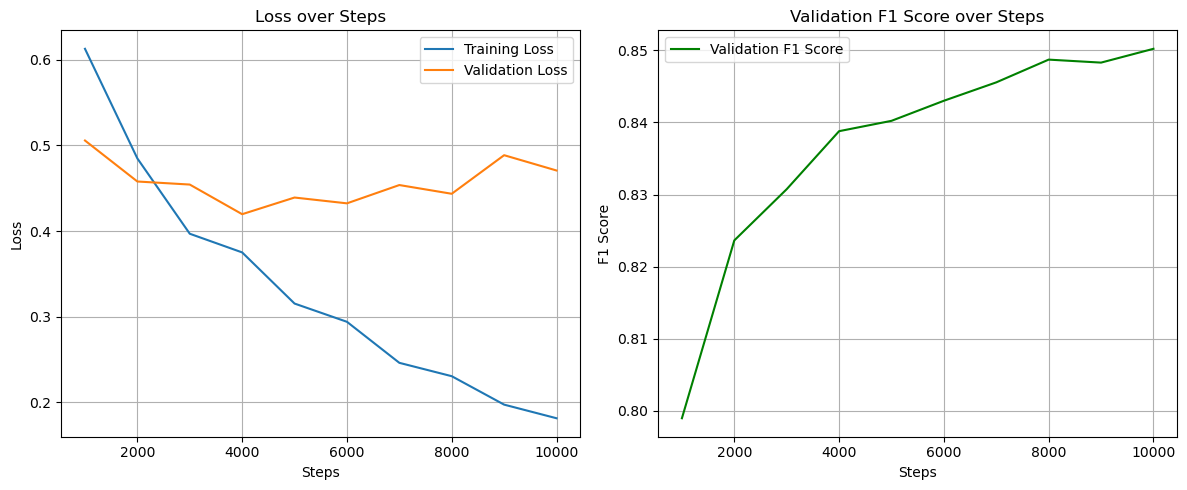

In [9]:
# prompt: vẽ hàm loss, F1

import matplotlib.pyplot as plt
import numpy as np

# Assuming the trainer object and training_args are available from the previous cell
# and trainer.train() has been called.

# Access the logs from the trainer
log_history = trainer.state.log_history

# Extract loss and F1 scores from the logs
train_loss = []
eval_loss = []
eval_f1 = []
steps = []

for entry in log_history:
    if 'loss' in entry:
        train_loss.append(entry['loss'])
        steps.append(entry['step'])
    if 'eval_loss' in entry:
        eval_loss.append(entry['eval_loss'])
    if 'eval_f1' in entry:
        eval_f1.append(entry['eval_f1'])

# Assuming evaluation is performed at regular intervals (steps)
# We need to align the steps for plotting
eval_steps = [entry['step'] for entry in log_history if 'eval_loss' in entry]

# Plotting the loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(steps[:len(train_loss)], train_loss, label='Training Loss')
plt.plot(eval_steps, eval_loss, label='Validation Loss')
plt.title('Loss over Steps')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting the F1 score
plt.subplot(1, 2, 2)
plt.plot(eval_steps, eval_f1, label='Validation F1 Score', color='green')
plt.title('Validation F1 Score over Steps')
plt.xlabel('Steps')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [17]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(steps[:len(train_loss)], train_loss, label='Training Loss')
plt.plot(eval_steps, eval_loss, label='Validation Loss')
plt.title('Loss over Steps')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(eval_steps, eval_f1, label='Validation F1 Score', color='green')
plt.title('Validation F1 Score over Steps')
plt.xlabel('Steps')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('gating_model/best_model/loss_f1_curve.png')
plt.close()

In [ ]:
gga

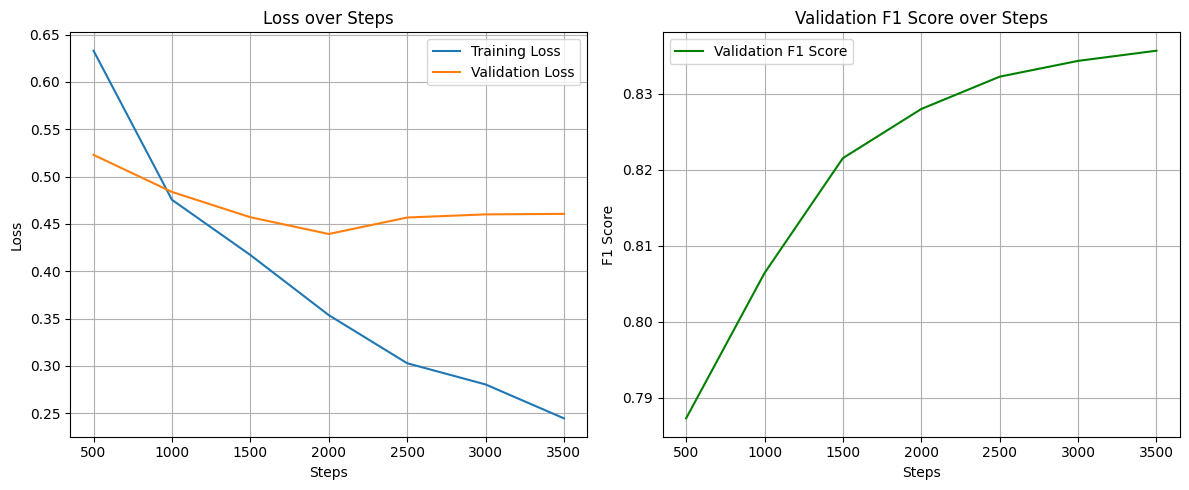

In [36]:
# prompt: vẽ hàm loss, F1

import matplotlib.pyplot as plt
import numpy as np

# Assuming the trainer object and training_args are available from the previous cell
# and trainer.train() has been called.

# Access the logs from the trainer
log_history = trainer.state.log_history

# Extract loss and F1 scores from the logs
train_loss = []
eval_loss = []
eval_f1 = []
steps = []

for entry in log_history:
    if 'loss' in entry:
        train_loss.append(entry['loss'])
        steps.append(entry['step'])
    if 'eval_loss' in entry:
        eval_loss.append(entry['eval_loss'])
    if 'eval_f1' in entry:
        eval_f1.append(entry['eval_f1'])

# Assuming evaluation is performed at regular intervals (steps)
# We need to align the steps for plotting
eval_steps = [entry['step'] for entry in log_history if 'eval_loss' in entry]

# Plotting the loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(steps[:len(train_loss)], train_loss, label='Training Loss')
plt.plot(eval_steps, eval_loss, label='Validation Loss')
plt.title('Loss over Steps')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting the F1 score
plt.subplot(1, 2, 2)
plt.plot(eval_steps, eval_f1, label='Validation F1 Score', color='green')
plt.title('Validation F1 Score over Steps')
plt.xlabel('Steps')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
trainer.train(resume_from_checkpoint='/content/drive/MyDrive/DATN/Preprocessing_data/gating_model/checkpoint-3500')

In [12]:
# prompt: làm sao để biết được đâu là model tốt nhất và lưu lại

# Để biết được đâu là model tốt nhất và lưu lại, bạn đã cấu hình `TrainingArguments`
# với `load_best_model_at_end=True` và `metric_for_best_model="f1"`.
# Điều này có nghĩa là sau khi quá trình huấn luyện kết thúc, `Trainer` sẽ tự động
# tải lại trọng số của mô hình có F1 score tốt nhất trên tập validation.

# Sau khi dòng `trainer.train()` hoàn thành, mô hình `trainer.model` đã là mô hình tốt nhất.
# Bạn chỉ cần gọi `trainer.save_model()` để lưu lại mô hình này.

# Dòng code dưới đây sẽ lưu lại mô hình tốt nhất vào thư mục `output_dir` đã được định nghĩa trong TrainingArguments.
# Nếu bạn muốn lưu vào một thư mục khác, bạn có thể truyền đường dẫn vào hàm `save_model`.
trainer.save_model("gating_model/best_model")

tokenizer.save_pretrained("" \
"gating_model/best_model")




('gating_model/best_model/tokenizer_config.json',
 'gating_model/best_model/special_tokens_map.json',
 'gating_model/best_model/vocab.txt',
 'gating_model/best_model/bpe.codes',
 'gating_model/best_model/added_tokens.json')

In [11]:
best_model = trainer.state.best_model_checkpoint
best_model

'gating_model/checkpoint-10000'

In [13]:
def predict_gating_label(text):
    encoding = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to(model.device)
    with torch.no_grad():
        outputs = model(**encoding)
    pred = torch.argmax(outputs.logits, dim=1).item()
    return id2label[pred]


In [14]:
predict_gating_label("Trời hôm nay mưa, tôi cảm thấy buồn")


'normal'

In [15]:
test_sentences = [
    "Hôm nay tôi cảm thấy khá bình thường, không có gì đặc biệt cả.",
    "Tôi thấy hơi lo lắng về tương lai và công việc.",
    "Gần đây tôi bị mất ngủ thường xuyên và không muốn gặp ai.",
    "Tôi cảm thấy chán nản và mất hết động lực sống.",
    "Tôi muốn tự tử. Tôi không thể chịu đựng được nữa.",
    "Mọi người đang đánh giá tôi, tôi không muốn ra khỏi nhà.",
    "Tôi đang ổn, chỉ hơi buồn một chút.",
    "Tôi bị rối loạn cảm xúc và không kiểm soát được hành vi của mình.",
]


In [16]:
for text in test_sentences:
    label = predict_gating_label(text)
    print(f"Text: {text}\nPredicted Gating Label: {label}\n")


Text: Hôm nay tôi cảm thấy khá bình thường, không có gì đặc biệt cả.
Predicted Gating Label: normal

Text: Tôi thấy hơi lo lắng về tương lai và công việc.
Predicted Gating Label: risky

Text: Gần đây tôi bị mất ngủ thường xuyên và không muốn gặp ai.
Predicted Gating Label: normal

Text: Tôi cảm thấy chán nản và mất hết động lực sống.
Predicted Gating Label: normal

Text: Tôi muốn tự tử. Tôi không thể chịu đựng được nữa.
Predicted Gating Label: emergency

Text: Mọi người đang đánh giá tôi, tôi không muốn ra khỏi nhà.
Predicted Gating Label: risky

Text: Tôi đang ổn, chỉ hơi buồn một chút.
Predicted Gating Label: emergency

Text: Tôi bị rối loạn cảm xúc và không kiểm soát được hành vi của mình.
Predicted Gating Label: risky

